In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

np.random.seed(847063)

# Exercício 1: Teorema Central do Limite

Considere o **Teorema Central do Limite (TCL)**. Sejam $X_1, \ldots, X_n$ variáveis aleatórias i.i.d., com média $\mu$ e variância finita $\sigma^2$. Então,

$$
\frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma}
\xrightarrow{d}
N(0,1),
$$

quando $n \to \infty$.

O objetivo deste exercício é verificar empiricamente o comportamento descrito pelo TCL para diferentes distribuições e diferentes valores de $n$.

1. Considere as seguintes distribuições para $X$:

   * Uniforme;
   * Bernoulli;
   * Geométrica;
   * Poisson.

   Para cada distribuição, escolha diferentes valores de $n$ e gere $M = 5000$ realizações da variável aleatória

   $$
   Z_n = \frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma}.
   $$

   Compare o comportamento da distribuição de $Z_n$ conforme o valor de $n$ aumenta.

2. Para cada distribuição e para cada valor de $n$, construa um histograma das $M = 5000$ realizações de $Z_n$.

   Compare os histogramas obtidos com uma amostra de uma distribuição normal padrão $N(0,1)$ gerada diretamente pelo NumPy.

3. Analise os resultados obtidos e discuta:

   * como a aproximação pela distribuição normal muda conforme $n$ aumenta;
   * quais distribuições apresentam convergência mais rápida para a normal;
   * como o formato da distribuição original influencia a qualidade da aproximação para valores pequenos de $n$.

# Testes Para Uniforme

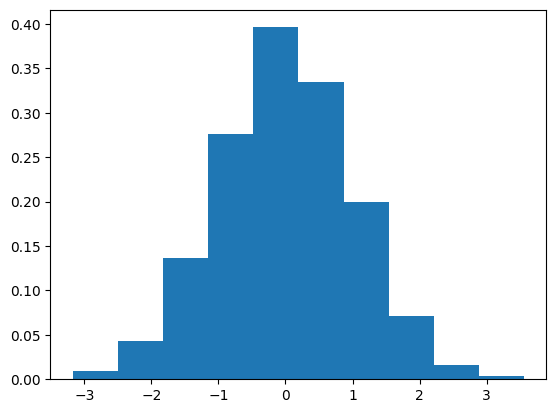

In [2]:
n = 10
m = 5000
amostra_final = []
for i in range(m):
  x_bar = np.mean(np.random.uniform(0, 1, n))
  amostra_final.append((np.sqrt(n)*(x_bar - 1/2))/np.sqrt(1/12))

plt.hist(amostra_final, density=True)
plt.show()

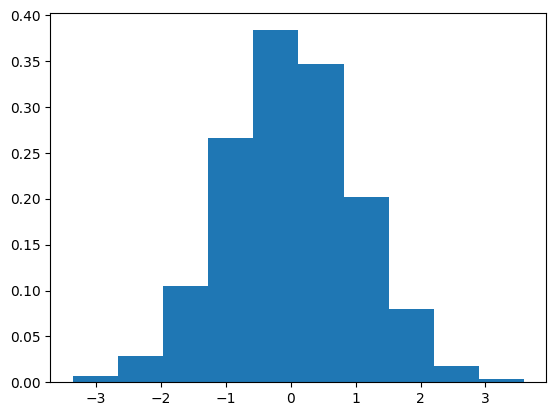

In [3]:
n = 100
m = 5000
amostra_final = []
for i in range(m):
  x_bar = np.mean(np.random.uniform(0, 1, n))
  amostra_final.append((np.sqrt(n)*(x_bar - 1/2))/np.sqrt(1/12))

plt.hist(amostra_final, density=True)
plt.show()

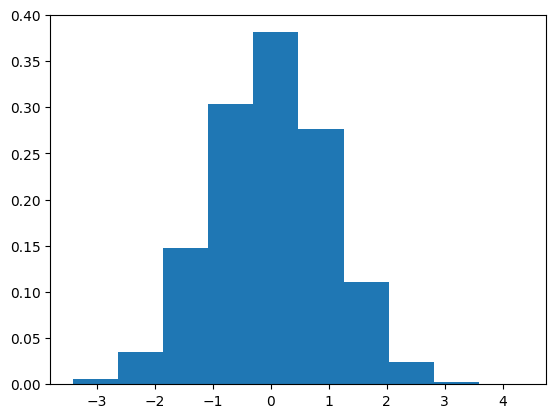

In [4]:
n = 500
m = 5000
amostra_final = []
for i in range(m):
  x_bar = np.mean(np.random.uniform(0, 1, n))
  amostra_final.append((np.sqrt(n)*(x_bar - 1/2))/np.sqrt(1/12))

plt.hist(amostra_final, density=True)
plt.show()

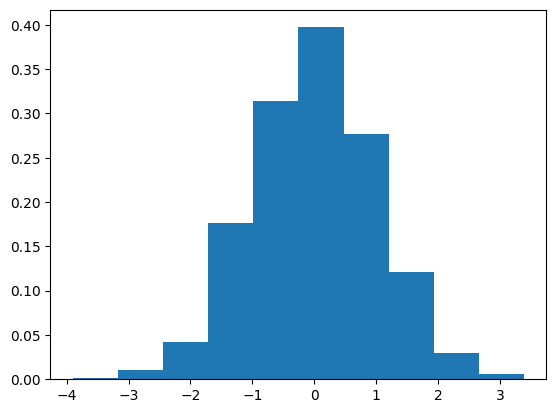

In [5]:
n = 1_000
m = 5000
amostra_final = []
for i in range(m):
  x_bar = np.mean(np.random.uniform(0, 1, n))
  amostra_final.append((np.sqrt(n)*(x_bar - 1/2))/np.sqrt(1/12))

plt.hist(amostra_final, density=True)
plt.show()

# Testes Para Bernoulli

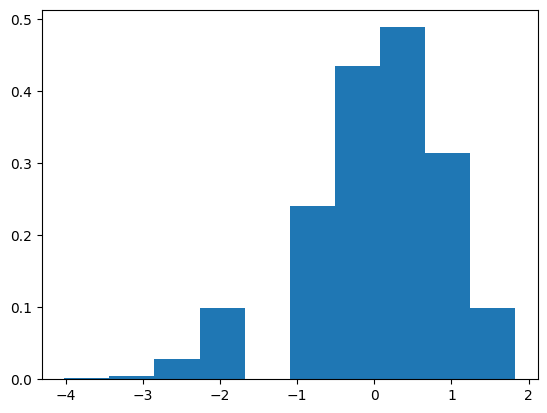

In [6]:
n = 10
p = 0.75
Bern = np.random.uniform(size=n)<p

amostra_final = []
for i in range(m):
  x_bar = np.mean(np.random.uniform(size=n)<p)
  amostra_final.append((n**0.5)*(x_bar - p)/((p*(1-p))**0.5))

plt.hist(amostra_final, density=True)
plt.show()

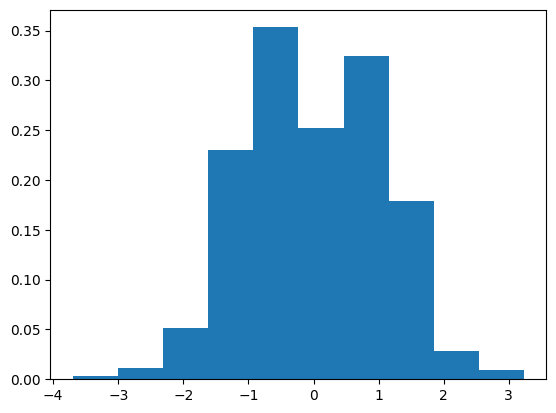

In [7]:
n = 100
p = 0.75
Bern = np.random.uniform(size=n)<p

amostra_final = []
for i in range(m):
  x_bar = np.mean(np.random.uniform(size=n)<p)
  amostra_final.append((n**0.5)*(x_bar - p)/((p*(1-p))**0.5))

plt.hist(amostra_final, density=True)
plt.show()

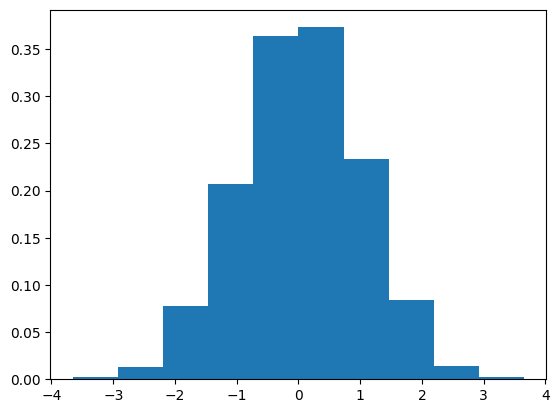

In [8]:
n = 1_000
p = 0.75
Bern = np.random.uniform(size=n)<p

amostra_final = []
for i in range(m):
  x_bar = np.mean(np.random.uniform(size=n)<p)
  amostra_final.append((n**0.5)*(x_bar - p)/((p*(1-p))**0.5))

plt.hist(amostra_final, density=True)
plt.show()

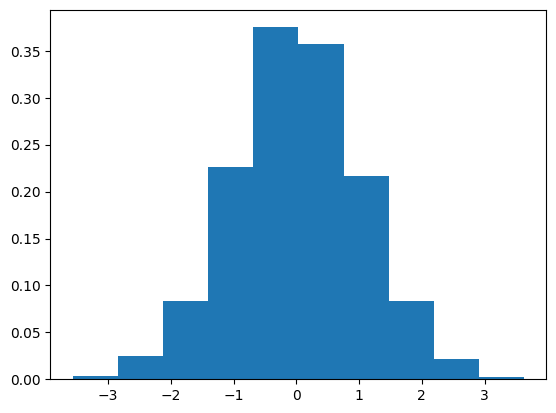

In [9]:
n = 10_000
p = 0.75
Bern = np.random.uniform(size=n)<p

amostra_final = []
for i in range(m):
  x_bar = np.mean(np.random.uniform(size=n)<p)
  amostra_final.append((n**0.5)*(x_bar - p)/((p*(1-p))**0.5))

plt.hist(amostra_final, density=True)
plt.show()

# Testes Para Geométrica

In [10]:
def geom(p, n):
  amostra = []
  for i in range(n):
    j = np.ceil(np.log(1 - np.random.uniform())/np.log(1-p))
    amostra.append(j)
  return amostra

def amostra_geom(p, n, M):
  amostra_final = []
  for i in range(M):
    x_bar = np.mean(geom(p, n))
    amostra_final.append((n**0.5)*(x_bar - 1/p)/(((1-p)/(p**2))**0.5))

  return amostra_final


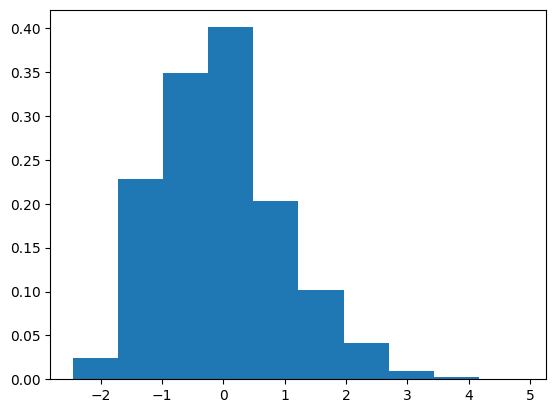

In [11]:
n = 10
m = 5000
p = 0.4

plt.hist(amostra_geom(p, n, m), density=True)
plt.show()

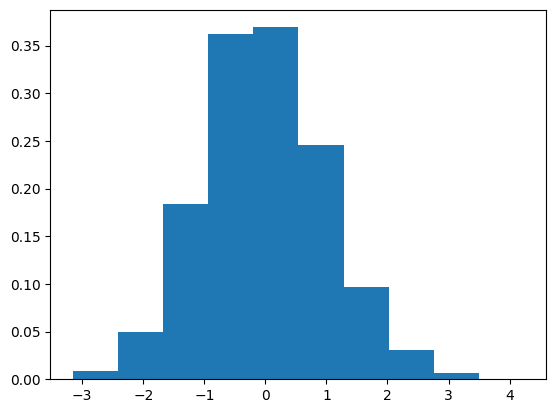

In [12]:
n = 100
m = 5_000
p = 0.4

plt.hist(amostra_geom(p, n, m), density=True)
plt.show()

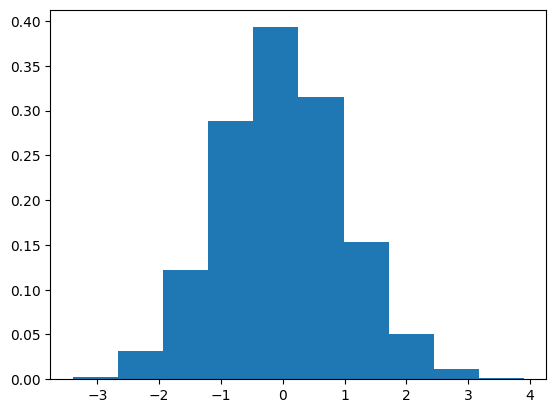

In [13]:
n = 500
m = 5_000
p = 0.4

plt.hist(amostra_geom(p, n, m), density=True)
plt.show()

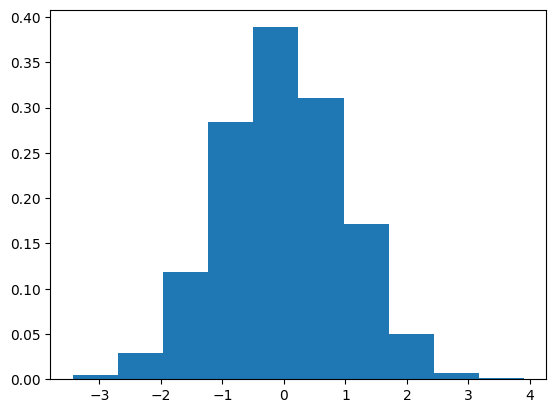

In [14]:
n = 1_000
m = 5_000
p = 0.4

plt.hist(amostra_geom(p, n, m), density=True)
plt.show()

# Testes Para Poisson

In [15]:
def poisson(lam, n):
  amostra = []
  for j in range(n):
    i = 0
    p0 = np.exp(-lam)
    F = p0
    u = np.random.uniform()
    while u > F:
      i += 1
      p0 = p0 * (lam/i)
      F += p0
    amostra.append(i)
  return amostra

def amostra_poisson(lam, n, M):
  amostra = []
  for i in range(M):
    x_bar = np.mean(poisson(lam, n))
    amostra.append((n**0.5)*(x_bar - lam)/((lam)**0.5))

  return amostra


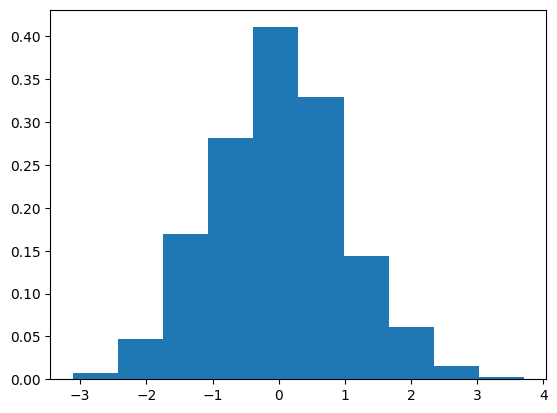

In [16]:
n = 10
m = 5_000
lam = 7

plt.hist(amostra_poisson(lam, n, m), density=True)
plt.show()

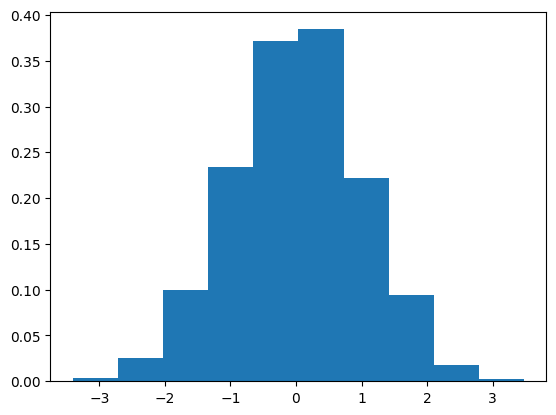

In [17]:
n = 100
m = 5_000
lam = 7

plt.hist(amostra_poisson(lam, n, m), density=True)
plt.show()

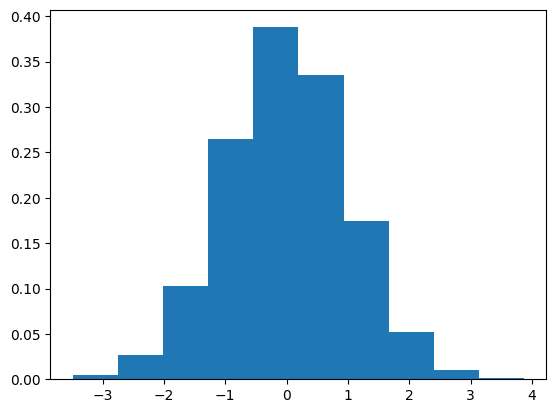

In [18]:
n = 500
m = 5_000
lam = 7

plt.hist(amostra_poisson(lam, n, m), density=True)
plt.show()

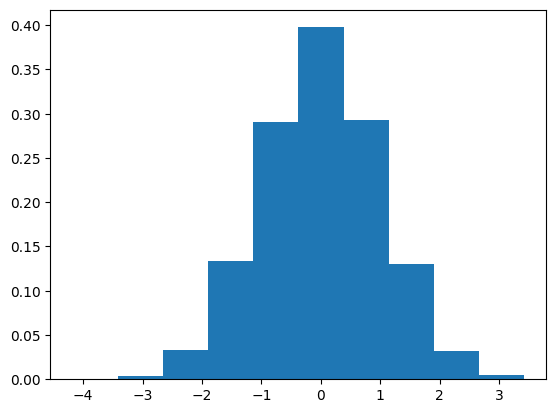

In [19]:
n = 1_000
m = 5_000
lam = 7

plt.hist(amostra_poisson(lam, n, m), density=True)
plt.show()

A Uniforme e a Poisson foram as distribuições que aparentaram exigir pouco "n" para obter uma boa aproximação para a Normal

# Exercício 2: Aproximação de Poisson

Como vimos em sala, se$X_n \sim \operatorname{Binomial}(n,p_n),$ com $p_n = \frac{\lambda}{n},$ então, para $\lambda > 0$ fixo,

$$
X_n \xrightarrow{d} \operatorname{Poisson}(\lambda)
$$

quando $n \to \infty$.

Em outras palavras, quando $n$ aumenta e $p_n$ diminui de forma que $np_n = \lambda,$ a distribuição $\operatorname{Binomial}(n,p_n)$ se aproxima de uma distribuição $\operatorname{Poisson}(\lambda)$.

1. Fixe um valor de $\lambda$ e um tamanho de amostra $M$. Para diferentes valores de $n$:

   * defina $p_n = \lambda/n$;
   * gere uma amostra de tamanho $M$ de variáveis

   $$
   X_n \sim \operatorname{Binomial}\left(n,\frac{\lambda}{n}\right);
   $$

   * compare as distribuições obtidas para diferentes valores de $n$ e analise o efeito do aumento de $n$ na aproximação pela distribuição de Poisson.

2. Para verificar a qualidade da aproximação, compare as amostras obtidas pelo método binomial com:

   * uma amostra de tamanho $M$ gerada diretamente por `numpy.random.poisson`;
   * uma amostra de tamanho $M$ de variáveis $\operatorname{Poisson}(\lambda)$ geradas utilizando o **método recursivo**.

3. Para cada método, construa histogramas ou gráficos de frequências e compare as distribuições empíricas obtidas.

4. Compare também o **tempo de execução** dos dois métodos:

   * aproximação por $\operatorname{Binomial}(n,\lambda/n)$;
   * geração de Poisson pelo método da inversão.

5. Discuta os resultados obtidos, considerando:

   * como o valor de $n$ influencia a qualidade da aproximação binomial-Poisson;
   * se as distribuições empíricas produzidas pelos três métodos são semelhantes;
   * as diferenças de tempo de execução entre os métodos;
   * as vantagens e desvantagens de cada método de geração.


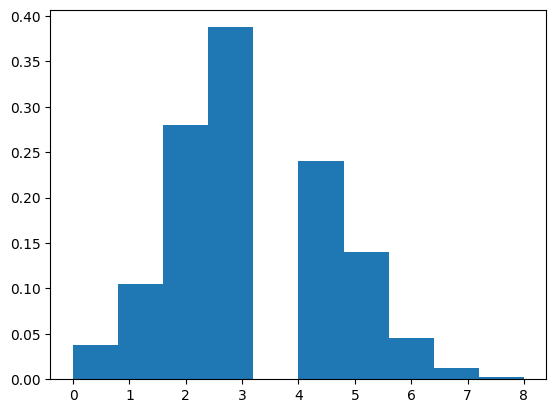

In [ ]:
lam = 3
n = 10
M = 500

amostra = np.sum(np.random.uniform(size=(M, n)) < lam/n, axis=1)
plt.hist(amostra, density=True)
plt.show()

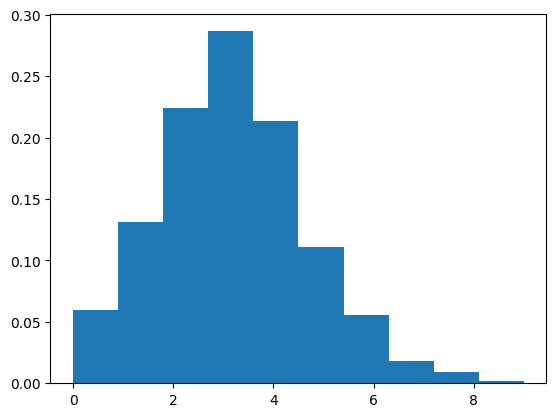

In [ ]:
lam = 3
n = 100
M = 500

amostra = np.sum(np.random.uniform(size=(M, n)) < lam/n, axis=1)
plt.hist(amostra, density=True)
plt.show()

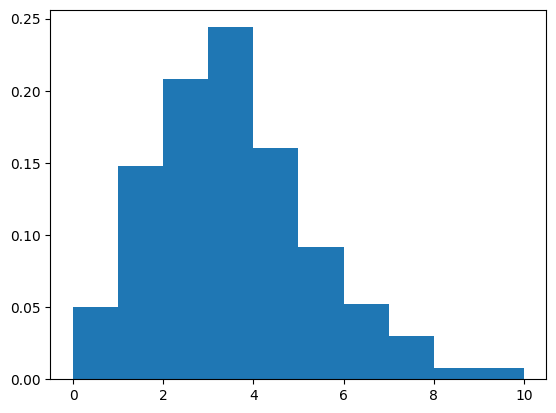

In [ ]:
lam = 3
n = 500
M = 500

amostra = np.sum(np.random.uniform(size=(M, n)) < lam/n, axis=1)
plt.hist(amostra, density=True)
plt.show()

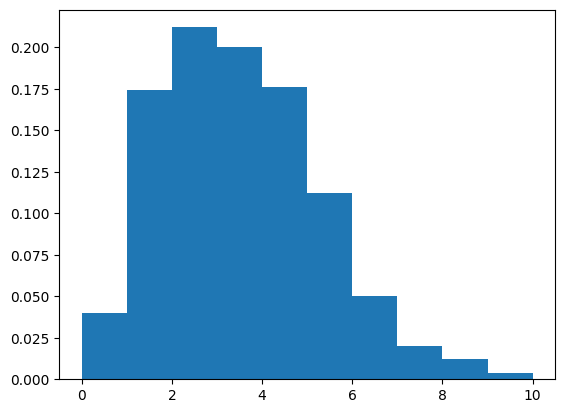

In [ ]:
lam = 3
n = 1000
M = 500

amostra = np.sum(np.random.uniform(size=(M, n)) < lam/n, axis=1)
plt.hist(amostra, density=True)
plt.show()

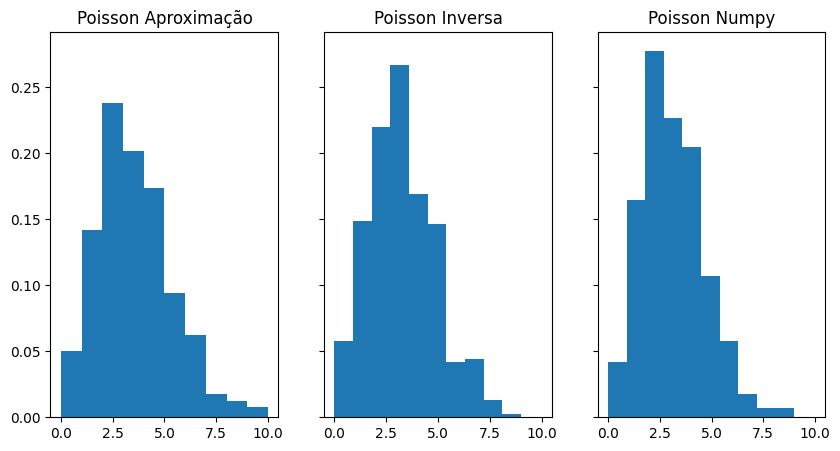

In [ ]:
lam = 3
n = 1000
M = 500

fig, ax = plt.subplots(1, 3, figsize=(10, 5), sharex=True, sharey=True)
ax[0].hist(np.sum(np.random.uniform(size=(M, n)) < lam/n, axis=1), density=True)
ax[0].set_title('Poisson Aproximação')
ax[1].hist(poisson(lam, M), density=True)
ax[1].set_title('Poisson Inversa')
ax[2].hist(np.random.poisson(lam, M), density=True)
ax[2].set_title('Poisson Numpy')

plt.show()

In [26]:
comeco = time.time()
np.sum(np.random.uniform(size=(M, n)) < lam/n, axis=1)
fim = time.time()
print(f"Tempo de execução da poisson por aproximação: {fim - comeco}")

comeco = time.time()
poisson(lam, M)
fim = time.time()
print(f"Tempo de execução da poisson inversa: {fim - comeco}")

Tempo de execução da poisson por aproximação: 0.008814096450805664
Tempo de execução da poisson inversa: 0.0038678646087646484


O n é o principal fator que influência a qualidade da aproximação da poisson por binomial, quanto maior o n maior a qualidade, contudo maior o tempo de execução também.

Em termos gerais o metodo da inversão é que apresenta melhores resultados, tanto de tempo de execução quanto de qualidade de aproximação. Deixando o metodo da aproximação por binomial como apenas uma opção didatica para apresentar a relação entre as variaveis.